# probs_for_cross
---------------
 Determine the probability for each cross-section by marginalising over both bahamas and darkskies

## Imports and functions

In [41]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
from get_model_probabilities import *

# Now run - but with all cuts for final inference

In [87]:
filter_list = ['concat','f150w','f115w']
target_test_accuracy = pkl.load(open("pickles/target_test_accuracy.pkl","rb"))


### MASS WEIGHTS FOR CALCULATING THE MEAN #####
zs = 1.65
zl = 0.305
critical_density = sigma_critical(zl, zs, Planck18).to(units.Msun/units.kpc/units.kpc)
bah_meta, bah_data = pkl.load(open("../data/shear/bahamas_cdm.pkl","rb"))
dar_meta, dar_data = pkl.load(open("../data/shear/darkskies_cdm.pkl","rb"))
mass_bah = np.log10(np.sum(np.sum(bah_data[:,2],axis=-1)*critical_density* (20*units.kpc)**2, axis=-1).value)
mass_dark = np.log10(np.sum(np.sum(dar_data[:,2],axis=-1)*critical_density* (20*units.kpc)**2, axis=-1).value)

yb, x = np.histogram(mass_bah, bins=np.linspace(14,15.5,30))
yd, x = np.histogram(mass_dark, bins=np.linspace(14,15.5,30))

mass_weights = {'src':{'x':x, 'y':1./yb},'tgt':{'x':x, 'y':1./yd}} 
#######


for ifx, ifilter in enumerate(filter_list):
    results_file = f"pickles/all_models_{ifilter}_zs_results.pkl"
    if not os.path.isfile( results_file ):
        continue
    all_results = pkl.load(open(results_file,"rb"))


    
    positive_mass, mass_cut = get_mass_cut( ifilter, study='harvey')
    

    domain = {
        'tgt':'darkskies_obs',
        'src':'bahamas_obs'
    }
    model_index = {}

    probs_for_cross = {}

    for imx, imodel in tqdm(enumerate(all_results.keys())):
        
        #if target_test_accuracy[ifilter][imodel]['target_test_f1'] <0.48:
        #    continue
        imodel_probs = {}
        imodel_index = {}

        for target in all_results[imodel].keys():
            tgt = get_threshold_for_cross( 
                    all_results[imodel][target], 
                    mass_cut=mass_cut, 
                    dataset=domain[target].split('_')[0],
                    integrated_mass=True,
                    mass_weights=mass_weights[target],
                    quiet=False)
            
            for idx, icross in enumerate(tgt['cross_sections']):
                keyname = f"{icross:0.2f}"
                if keyname not in imodel_probs.keys():
                    imodel_probs[ keyname ] = []
                    imodel_index[ keyname ] = []

                imodel_probs[keyname].append(
                    tgt['probabilities'][idx][:,0]
                )
                imodel_index[keyname].append(tgt['indexes'][idx])

        for ikey in imodel_probs.keys():
            if ikey not in probs_for_cross:
                probs_for_cross[ikey] = []
                model_index[ikey] = []


            model_index[ikey].append(np.hstack(imodel_index[ikey]))
            probs_for_cross[ikey].append(np.hstack(imodel_probs[ikey]))

    pkl.dump([model_index,probs_for_cross], open(f"pickles/probs_for_cross_{ifilter}_nob1.pkl","wb"))

30it [00:58,  1.94s/it]
30it [00:56,  1.89s/it]
30it [00:57,  1.91s/it]


In [81]:
def g1_func( snr, a, b, c, d ):
    d -= 1
    return a + b*np.exp( snr /c) - d*snr
    #return a + b*snr + c*snr**2
    #return a+b*snr

def g1_inv( snr, a, b, c, d):
    
    #return np.log((snr - a)/b)*c
    d -= 1
    
    return ( snr - a)/d - c*lambertw( b/(c*d)*np.exp((snr-a)/(c*d)))
    #return (snr -a)/b
    
def jacob( snr, a, b, c, d):
    d -= 1
    z = b/(c*d)*np.exp((snr-a)/(c*d))
    
    deriv = c*lambertw(z) / (z*(1+lambertw(z) ))
    return snr/d - deriv

    #return c/(snr-a)
    #return 1./b

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Mean Model Output')

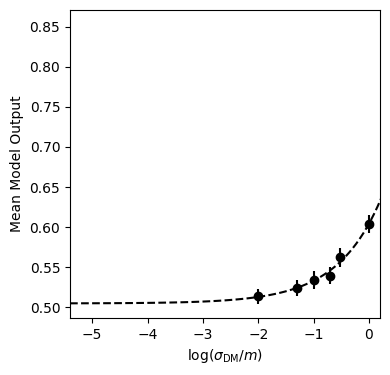

In [82]:

models, probs = pkl.load(open("pickles/probs_for_cross_concat_nob1.pkl","rb"))
models, probabilities, probabilities_noise =pkl.load(open("pickles/model_on_data.pkl","rb"))
nmodels = probabilities[ifilter].shape[0]

thresholds = 1.-np.array([ np.mean(np.concatenate([ j for j in probs[i]])) for i in probs.keys()])

err = np.array([ np.std(np.concatenate([ j for j in probs[i]]))/np.sqrt(30.) for i in probs.keys()])
cross = np.array([float(i) for i in probs.keys() ])

cdm_thresh = thresholds[ cross == 0]
cdm_err = err[ cross == 0]


err = err[ cross != 0 ]
thresholds = thresholds[ cross != 0 ]
cross = cross[ cross != 0]

#cross[cross==0] = 1e-3
cross = np.log10(cross)


    
## CURVE FITTING
popt, pcov = curve_fit(
                g1_func,
                cross,
                thresholds,
                p0=[1,1,1,-1],
                bounds=(np.array([-np.inf,-np.inf,-np.inf,-np.inf]),
                        np.array([np.inf, np.inf, np.inf, 1])
                        ))

popt_err = np.sqrt(np.diag(pcov))

cdm_cross = g1_inv( cdm_thresh, *popt)


fig, ax = plt.subplots(1,1,figsize=(4,4))

fig.subplots_adjust(wspace=0.3)
#####################

###PLOT 1

#####################
ax.errorbar(cross,thresholds,err,fmt='ko')
ax.plot( cdm_cross, cdm_thresh, 'k*', ms=10)
xplot=np.linspace(-5.4,1,100)
ax.plot( xplot, g1_func(xplot, *popt),'k--')
#ax.set_ylim(0.48,0.56)
ax.set_xlim(-5.4,0.2)
ax.set_xlabel("log($\sigma_{\\rm DM}/m$)")
ax.set_ylabel("Mean Model Output")


# All halos for the "how correlated are models" plot

In [5]:
filter_list = ['concat','f150w','f115w']

for ifx, ifilter in enumerate(filter_list):
    all_results = pkl.load(open(f"pickles/all_models_{ifilter}_results.pkl","rb"))

    domain = {
        'tgt':'darkskies_obs',
        'src':'bahamas_obs'
    }
    model_index = {}

    probs_for_cross = {}

    for imx, imodel in tqdm(enumerate(all_results.keys())):
        
        #if target_test_accuracy[ifilter][imodel]['target_test_f1'] <0.48:
        #    continue
        imodel_probs = {}
        imodel_index = {}

        for target in all_results[imodel].keys():
            tgt = get_threshold_for_cross( 
                    all_results[imodel][target], 
                    mass_cut=None, 
                    dataset=domain[target].split('_')[0],
                    quiet=False)
            
            for idx, icross in enumerate(tgt['cross_sections']):
                keyname = f"{icross:0.2f}"
                if keyname not in imodel_probs.keys():
                    imodel_probs[ keyname ] = []
                    imodel_index[ keyname ] = []

                imodel_probs[keyname].append(
                    tgt['probabilities'][idx][:,0]
                )
                imodel_index[keyname].append(tgt['indexes'][idx])

        for ikey in imodel_probs.keys():
            if ikey not in probs_for_cross:
                probs_for_cross[ikey] = []
                model_index[ikey] = []


            model_index[ikey].append(np.hstack(imodel_index[ikey]))
            probs_for_cross[ikey].append(np.hstack(imodel_probs[ikey]))

    pkl.dump([model_index,probs_for_cross], open(f"pickles/probs_for_cross_{ifilter}_all_nob1.pkl","wb"))

30it [00:00, 82.79it/s]
30it [00:00, 83.48it/s]
30it [00:00, 83.67it/s]
